# Grad-CAM — large-font typographic attacks (EN vs ZH)

Same layout as `comparison.ipynb` §8, but with **CIFAR-10-style font overlay** (size 40 on 224×224 images) instead of the tiny text on native 32×32 pixels.

Columns: **Clean** | **EN attack** | **ZH attack**.  
Each cell: EN-model Grad-CAM (left) + ZH-model Grad-CAM (right).  
Below each panel: model prediction — **green = correct**, **red = fooled**.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'open_clip_torch', 'transformers', 'datasets',
                'matplotlib', 'Pillow'], check=False)

CompletedProcess(args=['D:\\ian\\2026summer\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', '-q', 'open_clip_torch', 'transformers', 'datasets', 'matplotlib', 'Pillow'], returncode=0)

In [2]:
import os, platform, random, json, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn.functional as F
import open_clip
from PIL import Image, ImageDraw, ImageFont
from datasets import load_dataset
from transformers import ChineseCLIPModel, ChineseCLIPProcessor

os.makedirs('results', exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


## 1. Models, classes, large-font overlay

In [3]:
LANGS = ['en', 'zh']

CLASSES = {
    'en': ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'],
    'zh': ['飞机','汽车','鸟','猫','鹿','狗','青蛙','马','船','卡车'],
}
TMPL = {'en': 'a photo of a {}.', 'zh': '一张{}的照片。'}
DISPLAY_SIZE = 224
FONT_SIZE = 40

def classify(model, imgs, words):
    imf = model.embed_images(imgs)
    tf  = model.embed_texts(words)
    return (imf @ tf.t()).argmax(-1).cpu().numpy()

def _clip_feat(out):
    if torch.is_tensor(out): return out
    if getattr(out, 'pooler_output', None) is not None: return out.pooler_output
    raise TypeError(type(out))

class EnCLIP:
    lang = 'en'
    def __init__(self):
        self.m, _, self.pp = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
        self.m = self.m.to(DEVICE).eval()
        self.tok = open_clip.get_tokenizer('ViT-B-32')
    @torch.no_grad()
    def embed_images(self, imgs):
        x = torch.stack([self.pp(im) for im in imgs]).to(DEVICE)
        return F.normalize(self.m.encode_image(x), dim=-1)
    @torch.no_grad()
    def embed_texts(self, words):
        t = self.tok([TMPL['en'].format(w) for w in words]).to(DEVICE)
        return F.normalize(self.m.encode_text(t), dim=-1)

class ZhCLIP:
    lang = 'zh'
    def __init__(self):
        self.m = ChineseCLIPModel.from_pretrained('OFA-Sys/chinese-clip-vit-base-patch16').to(DEVICE).eval()
        self.p = ChineseCLIPProcessor.from_pretrained('OFA-Sys/chinese-clip-vit-base-patch16')
    @torch.no_grad()
    def embed_images(self, imgs):
        pv = self.p(images=imgs, return_tensors='pt').pixel_values.to(DEVICE)
        return F.normalize(_clip_feat(self.m.get_image_features(pixel_values=pv)), dim=-1)
    @torch.no_grad()
    def embed_texts(self, words):
        t = self.p(text=[TMPL['zh'].format(w) for w in words], padding=True, return_tensors='pt').to(DEVICE)
        out = self.m.get_text_features(input_ids=t['input_ids'], attention_mask=t['attention_mask'],
                                        token_type_ids=t.get('token_type_ids'))
        return F.normalize(_clip_feat(out), dim=-1)

MODEL_CLS = {'en': EnCLIP, 'zh': ZhCLIP}

def _font_paths():
    if platform.system() == 'Windows':
        winfonts = os.path.join(os.environ.get('WINDIR', r'C:\Windows'), 'Fonts')
        cjk   = os.path.join(winfonts, 'msyh.ttc')
        latin = os.path.join(winfonts, 'arial.ttf')
        if not os.path.exists(latin):
            latin = cjk
        return cjk, latin
    cjk   = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
    latin = '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf'
    if not os.path.exists(cjk):
        cjk = '/usr/share/fonts/opentype/noto/NotoSansCJKsc-Regular.otf'
    return cjk, latin

CJK_FONT, LATIN_FONT = _font_paths()

def _font_for(word):
    for ch in word:
        if ord(ch) > 0x2E7F:
            return CJK_FONT
    return LATIN_FONT

def to_display(img):
    return img.convert('RGB').resize((DISPLAY_SIZE, DISPLAY_SIZE), Image.BICUBIC)

def draw_word(pil_img, word, font_path=None, size=FONT_SIZE, where='bottom'):
    """CIFAR-10 notebook style: upscale to 224 and render readable text."""
    if font_path is None:
        font_path = _font_for(word)
    img  = pil_img.convert('RGB').resize((DISPLAY_SIZE, DISPLAY_SIZE), Image.BICUBIC)
    d    = ImageDraw.Draw(img)
    font = ImageFont.truetype(font_path, size)
    bb   = d.textbbox((0, 0), word, font=font)
    w, h = bb[2] - bb[0], bb[3] - bb[1]
    x    = (DISPLAY_SIZE - w) // 2
    y    = (DISPLAY_SIZE - h - 16) if where == 'bottom' else (DISPLAY_SIZE - h) // 2
    d.rectangle([x - 8, y - 8, x + w + 8, y + h + 12], fill=(255, 255, 255))
    d.text((x - bb[0], y - bb[1]), word, fill=(0, 0, 0), font=font)
    return img

print('Fonts:', CJK_FONT, '|', LATIN_FONT)

Fonts: C:\WINDOWS\Fonts\msyh.ttc | C:\WINDOWS\Fonts\arial.ttf


## 2. Load shared CIFAR-10 subset + models

In [4]:
hf = load_dataset('uoft-cs/cifar10', split='test')
label_key = 'label' if 'label' in hf.column_names else 'labels'
image_key = 'img'   if 'img'   in hf.column_names else 'image'

_indices_path = '../shared/cifar10_1000_indices.json'
with open(_indices_path, encoding='utf-8') as f:
    saved = json.load(f)
idx = saved['idx']
target = np.array(saved['target'])
rows = hf.select(idx)
true = np.array(rows[label_key])
clean = [im.convert('RGB') for im in rows[image_key]]
print(f'Loaded {len(clean)} images from shared subset')

models = {}
for lang, cls in MODEL_CLS.items():
    t0 = time.time()
    print(f'Loading {lang}...', end=' ', flush=True)
    models[lang] = cls()
    print(f'{time.time()-t0:.1f}s')

Loaded 1000 images from shared subset
Loading en... 

D:\ian\2026summer\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


1.3s
Loading zh... 

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

2.0s


## 3. Grad-CAM heatmaps (large font, coloured predictions)

D:\ian\2026summer\.venv\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


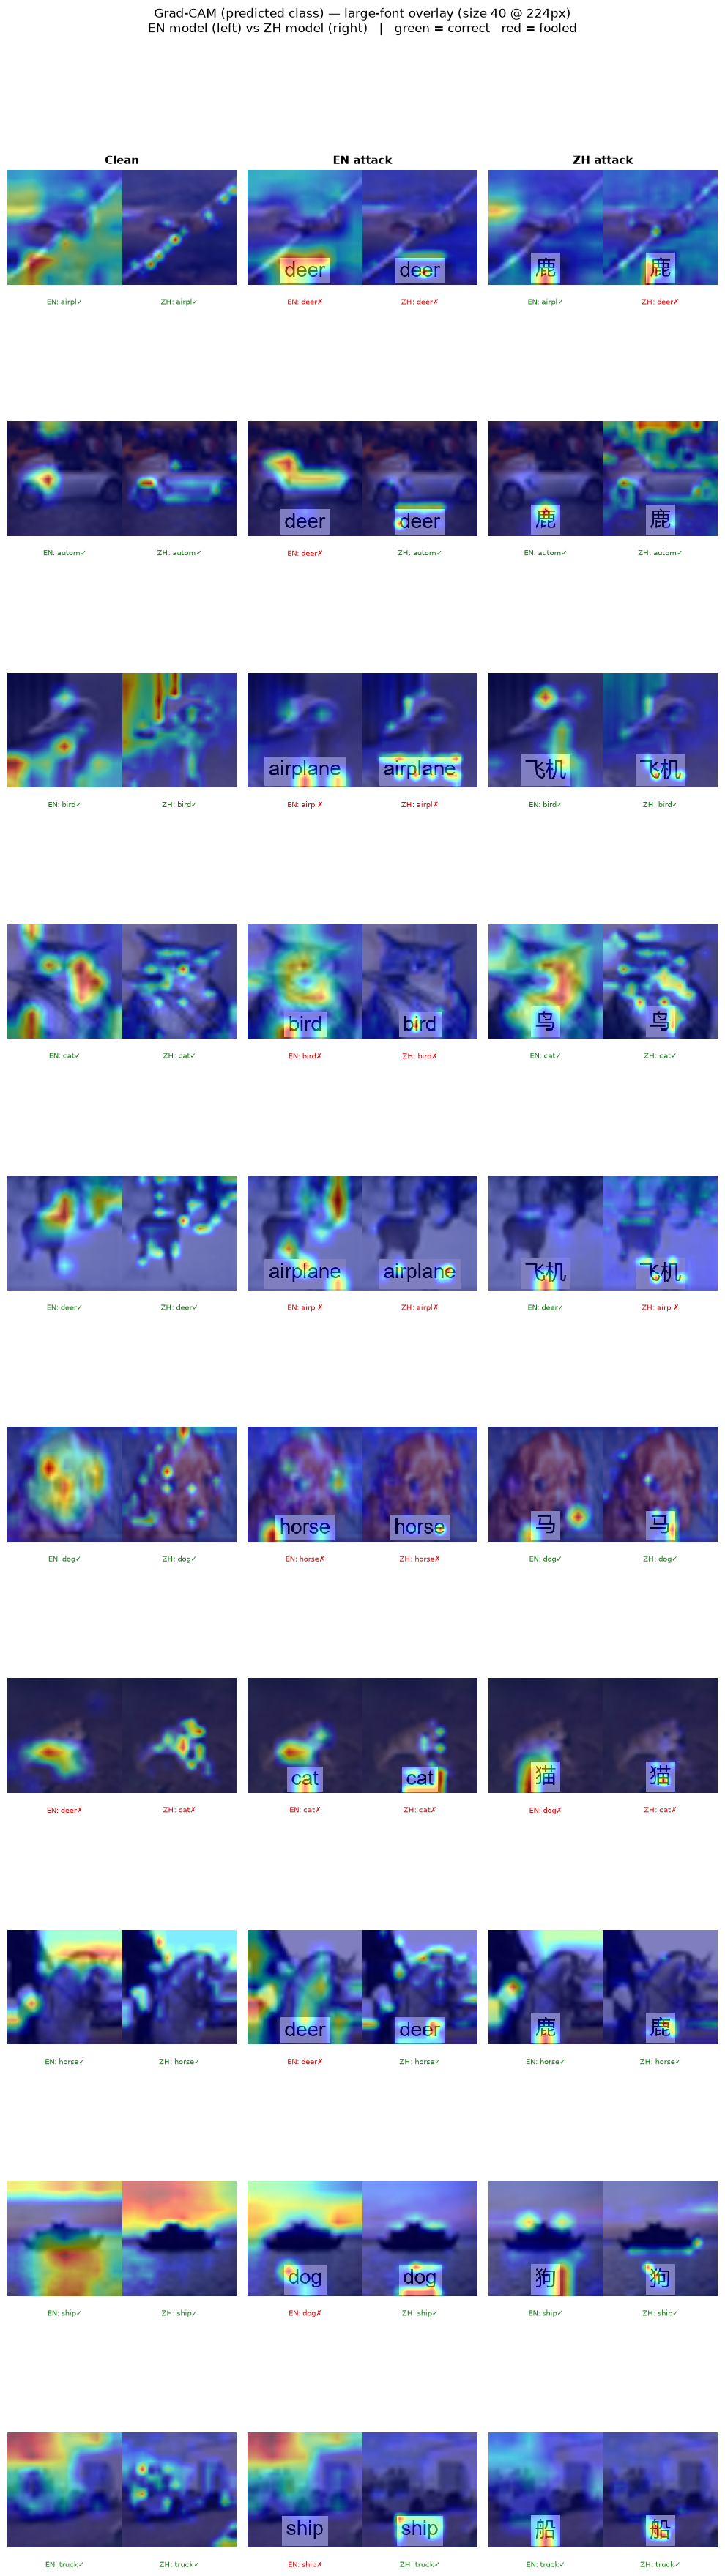

Saved -> results/gradcam_heatmaps_large_font.png


In [5]:
TEXT_EMB = {lang: models[lang].embed_texts(CLASSES[lang]).detach() for lang in LANGS}

def _norm_cam(cam):
    cam = cam.relu() if isinstance(cam, torch.Tensor) else np.maximum(cam, 0)
    cam = cam.detach().cpu().numpy() if isinstance(cam, torch.Tensor) else cam
    cam = cam - cam.min()
    mx = cam.max()
    return cam / mx if mx > 0 else cam

def _cam_from_conv(act, grad):
    w = grad.mean(dim=(2, 3), keepdim=True)
    return _norm_cam((w * act).sum(dim=1).squeeze(0))

def gradcam_en(pil_img, target_idx):
    wrapper = models['en']
    acts = {}
    def hook(_m, _i, out):
        out.retain_grad()
        acts['v'] = out
    handle = wrapper.m.visual.conv1.register_forward_hook(hook)
    x = wrapper.pp(pil_img).unsqueeze(0).to(DEVICE)
    feat = wrapper.m.visual(x)
    img_feat = F.normalize(feat, dim=-1)
    score = (img_feat @ TEXT_EMB['en'][target_idx:target_idx + 1].T).squeeze()
    wrapper.m.zero_grad()
    score.backward()
    cam = _cam_from_conv(acts['v'].detach(), acts['v'].grad)
    handle.remove()
    return cam

def gradcam_zh(pil_img, target_idx):
    wrapper = models['zh']
    acts = {}
    patch = wrapper.m.vision_model.embeddings.patch_embedding
    def hook(_m, _i, out):
        out.retain_grad()
        acts['v'] = out
    handle = patch.register_forward_hook(hook)
    pv = wrapper.p(images=[pil_img], return_tensors='pt').pixel_values.to(DEVICE)
    out = wrapper.m.get_image_features(pixel_values=pv)
    img_feat = F.normalize(_clip_feat(out), dim=-1)
    score = (img_feat @ TEXT_EMB['zh'][target_idx:target_idx + 1].T).squeeze()
    wrapper.m.zero_grad()
    score.backward()
    cam = _cam_from_conv(acts['v'].detach(), acts['v'].grad)
    handle.remove()
    return cam

GRADCAM_FN = {'en': gradcam_en, 'zh': gradcam_zh}

def overlay_cam(pil_img, cam, alpha=0.50):
    h, w = pil_img.size[1], pil_img.size[0]
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
    heat = cm.jet(np.array(cam_img) / 255.0)[:, :, :3]
    base = np.array(pil_img).astype(np.float32) / 255.0
    blended = np.clip((1 - alpha) * base + alpha * heat, 0, 1)
    return Image.fromarray((blended * 255).astype(np.uint8))

def cam_for_model(model_lang, pil_img):
    pred = int(classify(models[model_lang], [pil_img], CLASSES[model_lang])[0])
    cam = GRADCAM_FN[model_lang](pil_img, pred)
    return overlay_cam(pil_img, cam), pred

def pred_labels_cam(ax, preds_by_model, true_class, y=-0.12):
    """Green = correct, red = fooled — one label per model half."""
    for j, ml in enumerate(LANGS):
        pred = int(preds_by_model[ml])
        ok   = (pred == true_class)
        col  = '#1a7a1a' if ok else '#cc1111'
        sym  = '\u2713' if ok else '\u2717'
        ax.text((j + 0.5) / len(LANGS), y,
                f"{ml.upper()}: {CLASSES['en'][pred][:5]}{sym}",
                transform=ax.transAxes, fontsize=7, color=col,
                ha='center', va='top', clip_on=False)

cam_select = [(c, int(np.where(true == c)[0][0])) for c in range(10)]
cond_specs = [
    ('Clean',     lambda pos: to_display(clean[pos])),
    ('EN attack', lambda pos: draw_word(clean[pos], CLASSES['en'][target[pos]], where='bottom')),
    ('ZH attack', lambda pos: draw_word(clean[pos], CLASSES['zh'][target[pos]], where='bottom')),
]

fig, axes = plt.subplots(10, 3, figsize=(10, 36))
fig.suptitle(
    'Grad-CAM (predicted class) — large-font overlay (size 40 @ 224px)\n'
    'EN model (left) vs ZH model (right)   |   green = correct   red = fooled',
    fontsize=12, y=1.005)

for ax, title in zip(axes[0], [s[0] for s in cond_specs]):
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

for row_i, (c, pos) in enumerate(cam_select):
    for col_i, (_, img_fn) in enumerate(cond_specs):
        src_img = img_fn(pos)
        panels = []
        preds = {}
        for ml in LANGS:
            panel, pred = cam_for_model(ml, src_img)
            panels.append(panel)
            preds[ml] = pred
        combined = Image.new('RGB', (DISPLAY_SIZE * 2, DISPLAY_SIZE))
        combined.paste(panels[0], (0, 0))
        combined.paste(panels[1], (DISPLAY_SIZE, 0))
        ax = axes[row_i, col_i]
        ax.imshow(combined, interpolation='nearest')
        ax.axis('off')
        if col_i == 0:
            ax.set_ylabel(CLASSES['en'][c], fontsize=9, rotation=0, labelpad=42, va='center')
        pred_labels_cam(ax, preds, c)

plt.tight_layout()
out = 'results/gradcam_heatmaps_large_font.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print('Saved ->', out)